# Scraping Land — Tratamiento de Outliers

Notebook dedicado al análisis y eliminación de outliers del dataset de terrenos.

**Input:** `data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv`  
(generado por `scraping_land_processing`; sin tratamiento de outliers)

**Pipeline:**
1. EDA – análisis exploratorio previo
2. Comparativa de métodos de detección de outliers
3. Pipeline unificado: Regla fija → IQR ×3.0 → Regla precio > 300k → IQR ×1.5

**Output:** `data/processed/scraping_manual/total_land_cantabria_outliers.csv`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Carga del dataset procesado

Se carga `scraping_land_preprocessed.csv` (dataset limpio, sin outliers eliminados) y se trabaja sobre una copia.

In [2]:
csv_candidates = [
    Path("../../data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv"),
    Path("data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv")
]
csv_path = next((p for p in csv_candidates if p.exists()), csv_candidates[0])

df_raw = pd.read_csv(csv_path, sep=';')
df_final = df_raw.copy()

print(f"CSV cargado desde: {csv_path}")
print(f"Shape: {df_final.shape}")
df_final.head(3)

CSV cargado desde: ../../data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv
Shape: (967, 8)


,titulo,municipio,precio_eur,superficie_m2,tipo_suelo,vendido_con_descuento,es_urbano_o_urbanizable,precio_m2
0,"Oruña, Piélagos",Piélagos,139000,965.0,Urbano (solar),False,True,144.041451
1,"Peñacastillo - Nuevamontaña, Santander",Santander,169000,650.0,Urbano (solar),False,True,260.000000
2,"Calle de la Arnia, Soto de la Marina, Santa Cr...",Santa Cruz de Bezana,1290000,3217.0,Urbano (solar),False,True,400.994716


---
## 2. EDA – Análisis Exploratorio previo a la detección de outliers

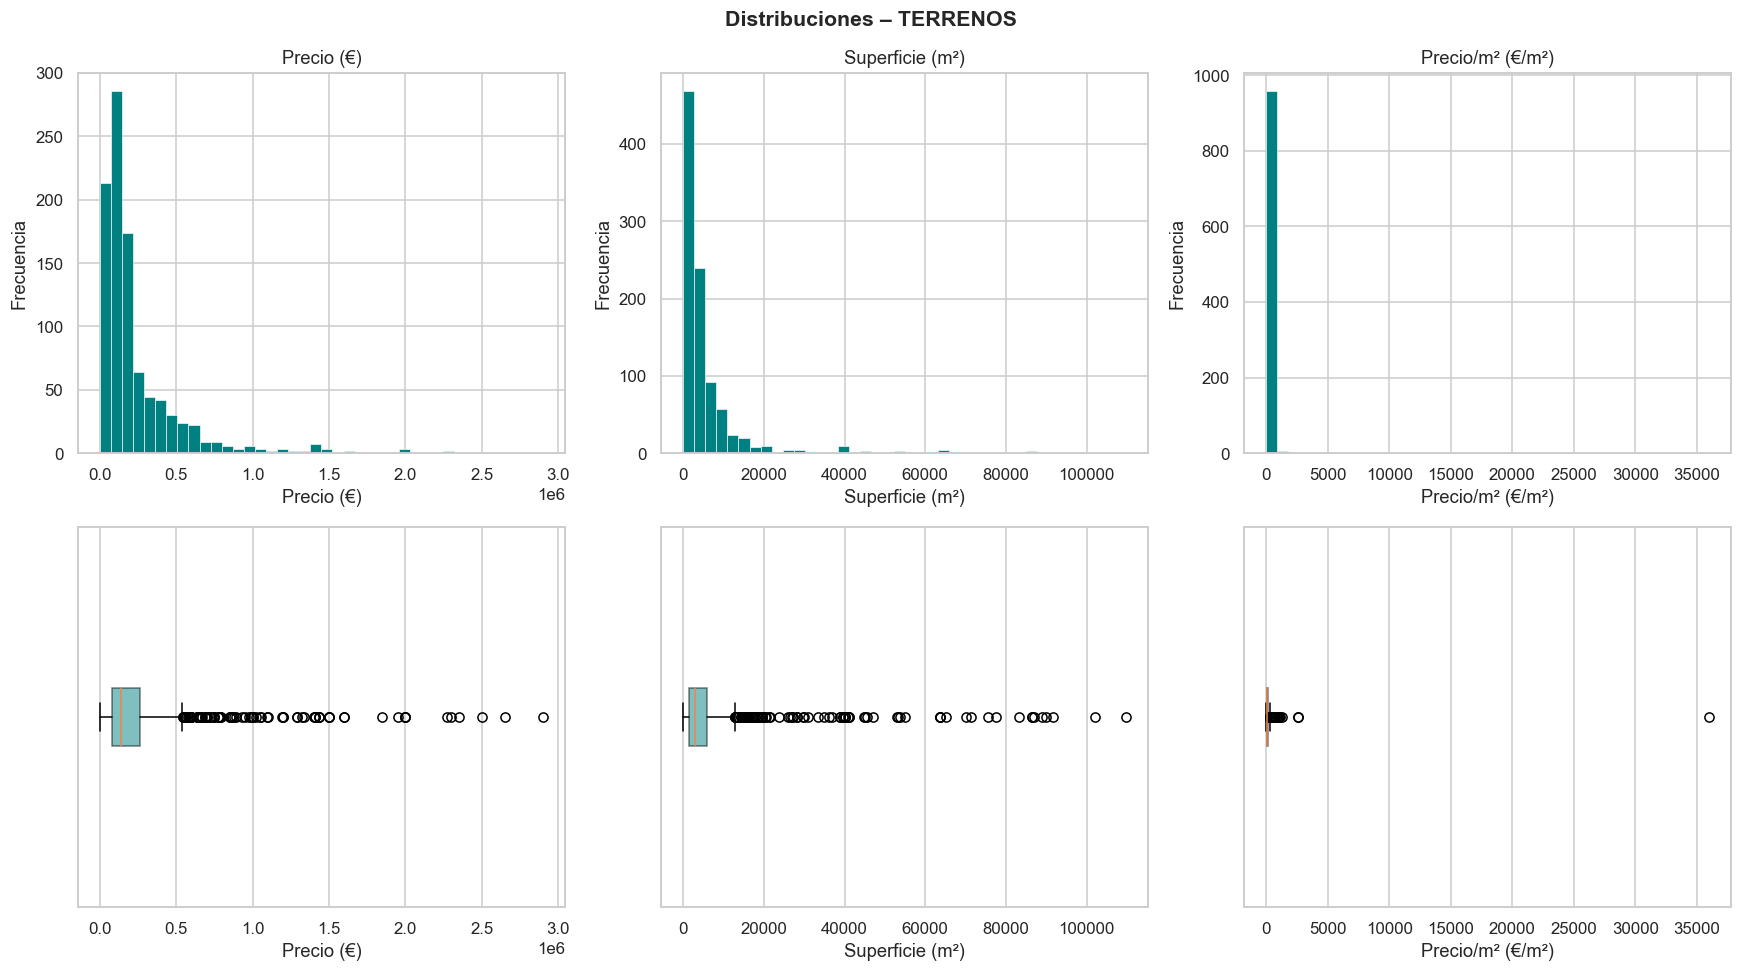

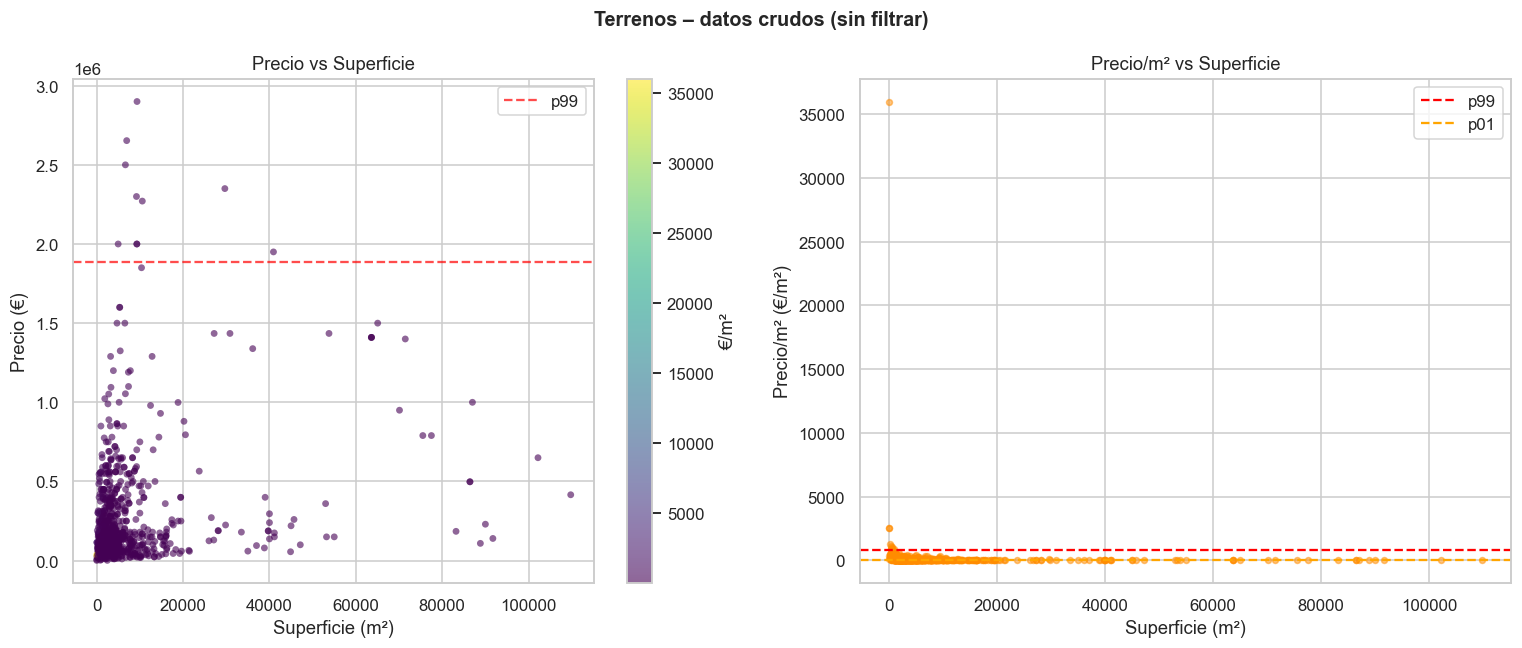

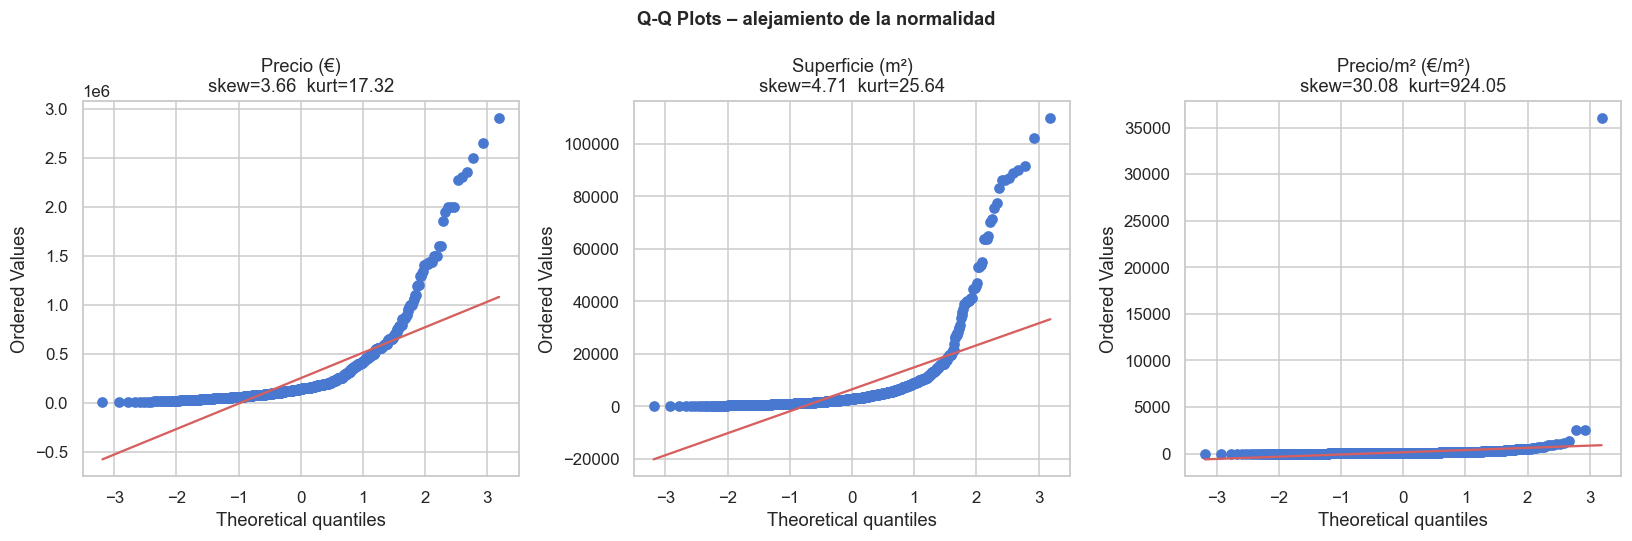

Distribuciones asimétricas (skew > 1) → la regla 3-sigma clásica eliminará demasiado.


In [3]:
# ── Distribuciones ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuciones – TERRENOS', fontsize=14, fontweight='bold')

cols_eda   = ['precio_eur', 'superficie_m2', 'precio_m2']
labels_eda = ['Precio (€)', 'Superficie (m²)', 'Precio/m² (€/m²)']

for i, (col, label) in enumerate(zip(cols_eda, labels_eda)):
    data = df_final[col].dropna()
    axes[0, i].hist(data, bins=40, color='teal', edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Frecuencia')
    axes[1, i].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='teal', alpha=0.5))
    axes[1, i].set_xlabel(label)
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

# ── Scatter precio vs superficie ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Terrenos – datos crudos (sin filtrar)', fontsize=13, fontweight='bold')

sub = df_final.dropna(subset=['precio_eur', 'superficie_m2'])
sc  = axes[0].scatter(sub['superficie_m2'], sub['precio_eur'],
                      c=sub['precio_m2'], cmap='viridis',
                      alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='€/m²')
axes[0].set_title('Precio vs Superficie')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€)')
axes[0].axhline(sub['precio_eur'].quantile(0.99), color='red', linestyle='--',
                alpha=0.7, label='p99')
axes[0].legend()

sub2 = df_final.dropna(subset=['precio_m2', 'superficie_m2'])
axes[1].scatter(sub2['superficie_m2'], sub2['precio_m2'], alpha=0.5, s=15, color='darkorange')
axes[1].axhline(sub2['precio_m2'].quantile(0.99), color='red', linestyle='--', label='p99')
axes[1].axhline(sub2['precio_m2'].quantile(0.01), color='orange', linestyle='--', label='p01')
axes[1].set_title('Precio/m² vs Superficie')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio/m² (€/m²)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Q-Q plots + skewness ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q-Q Plots – alejamiento de la normalidad', fontsize=12, fontweight='bold')

for ax, col, label in zip(axes, cols_eda, labels_eda):
    d = df_final[col].dropna()
    stats.probplot(d, dist='norm', plot=ax)
    ax.set_title(f"{label}\nskew={d.skew():.2f}  kurt={d.kurtosis():.2f}")

plt.tight_layout()
plt.show()
print("Distribuciones asimétricas (skew > 1) → la regla 3-sigma clásica eliminará demasiado.")

---
## 3. Métodos de detección de outliers

Variables analizadas: `precio_eur`, `superficie_m2`, `precio_m2`

| # | Método | Asume normalidad | Variables | Agresividad |
|---|--------|-----------------|-----------|-------------|
| 1 | **Regla fija** | No | Univariante | Configurable |
| 2 | **IQR (1.5×)** | No | Univariante | Media |
| 3 | **Z-score sobre log** | Sí (en log) | Univariante | Baja |
| 4 | **Isolation Forest** | No | Multivariante | Alta (configurable) |

Regla fija:
  [Terrenos]  outliers=71  (7.3%)  → quedan 896

IQR ×1.5:
  [Terrenos]  outliers=224  (23.2%)  → quedan 743
IQR ×3.0:
  [Terrenos]  outliers=121  (12.5%)  → quedan 846

Z-log 3.0σ:
  [Terrenos]  outliers=9  (0.9%)  → quedan 958
Z-log 2.5σ:
  [Terrenos]  outliers=42  (4.3%)  → quedan 925

Isolation Forest contamination=0.05:
  [Terrenos]  outliers=49  (5.1%)  → quedan 918

Isolation Forest contamination=0.02:
  [Terrenos]  outliers=20  (2.1%)  → quedan 947


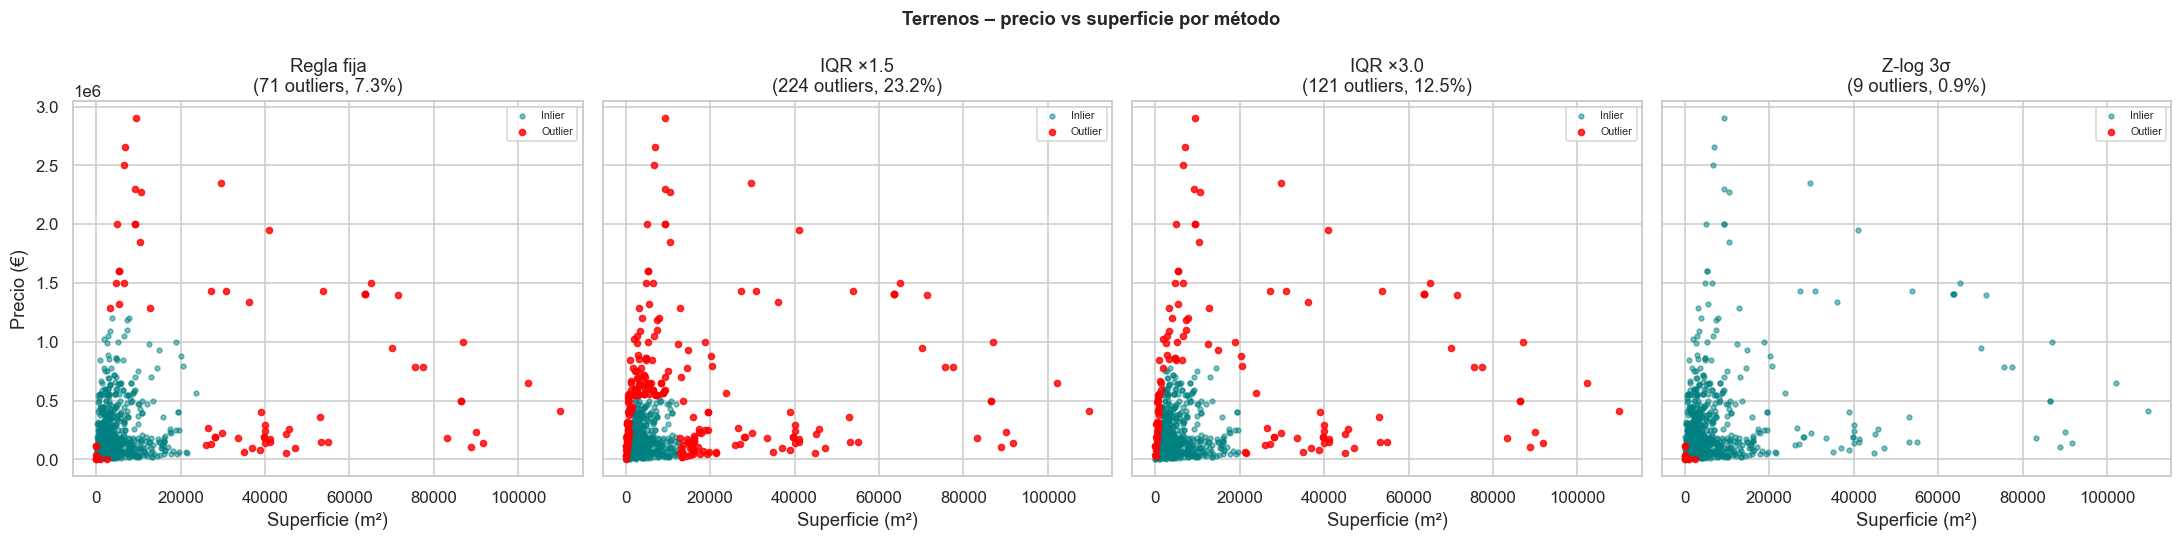

,Outliers,%,Restantes
Método,,,
Regla fija,71,7.3%,896
IQR ×1.5,224,23.2%,743
IQR ×3.0,121,12.5%,846
Z-log 3.0σ,9,0.9%,958
Z-log 2.5σ,42,4.3%,925


In [4]:
# ── Funciones auxiliares ──────────────────────────────────────────────────
def resumen_land(nombre, df_orig, mask_out):
    n = mask_out.sum()
    print(f"  [{nombre}]  outliers={n:,}  ({100*n/len(df_orig):.1f}%)  → quedan {len(df_orig)-n:,}")

def mask_iqr_land(df, cols, factor=1.5):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        d = df[col].dropna()
        q1, q3 = d.quantile(0.25), d.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - factor * iqr, q3 + factor * iqr
        mask |= df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    return mask

def mask_zscore_log_land(df, cols, threshold=3.0):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        series = df[col]
        valid  = series[series > 0].dropna()
        log_v  = np.log(valid)
        z      = (log_v - log_v.mean()) / log_v.std()
        mask |= df.index.isin(z[z.abs() > threshold].index)
    return mask

LAND_COLS = ['precio_eur', 'superficie_m2', 'precio_m2']

# ── Método 1: Regla fija ──────────────────────────────────────────────────
PRECIO_MIN,     PRECIO_MAX     = 5_000,   1_200_000
SUPERFICIE_MIN, SUPERFICIE_MAX = 50,      25_000
PBM_MIN,        PBM_MAX        = 0.5,     8_000

def mask_rf_land(df):
    return (
        df['precio_eur'].between(PRECIO_MIN, PRECIO_MAX) &
        df['superficie_m2'].between(SUPERFICIE_MIN, SUPERFICIE_MAX) &
        (df['precio_m2'].isna() | df['precio_m2'].between(PBM_MIN, PBM_MAX))
    )

m1_out = ~mask_rf_land(df_final)
print("Regla fija:")
resumen_land('Terrenos', df_final, m1_out)

# ── Método 2: IQR ×1.5 y ×3.0 ────────────────────────────────────────────
m2a_out = mask_iqr_land(df_final, LAND_COLS, 1.5)
m2b_out = mask_iqr_land(df_final, LAND_COLS, 3.0)
print("\nIQR ×1.5:")
resumen_land('Terrenos', df_final, m2a_out)
print("IQR ×3.0:")
resumen_land('Terrenos', df_final, m2b_out)

# ── Método 3: Z-score sobre log ───────────────────────────────────────────
m3a_out = mask_zscore_log_land(df_final, LAND_COLS, 3.0)
m3b_out = mask_zscore_log_land(df_final, LAND_COLS, 2.5)
print("\nZ-log 3.0σ:")
resumen_land('Terrenos', df_final, m3a_out)
print("Z-log 2.5σ:")
resumen_land('Terrenos', df_final, m3b_out)

# ── Método 4: Isolation Forest ────────────────────────────────────────────
sub_if = df_final[LAND_COLS].copy().fillna(df_final[LAND_COLS].median())
for cont in [0.05, 0.02]:
    clf   = IsolationForest(contamination=cont, random_state=42)
    preds = clf.fit_predict(sub_if)
    m4    = pd.Series(preds == -1, index=df_final.index)
    print(f"\nIsolation Forest contamination={cont}:")
    resumen_land('Terrenos', df_final, m4)

# ── Scatter comparativo ───────────────────────────────────────────────────
sub_plot = df_final.dropna(subset=['superficie_m2', 'precio_eur'])
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Terrenos – precio vs superficie por método', fontsize=12, fontweight='bold')

for ax, (mask, label) in zip(axes, [
    (m1_out,  'Regla fija'),
    (m2a_out, 'IQR ×1.5'),
    (m2b_out, 'IQR ×3.0'),
    (m3a_out, 'Z-log 3σ'),
]):
    m = mask.reindex(sub_plot.index).fillna(False)
    ax.scatter(sub_plot.loc[~m, 'superficie_m2'], sub_plot.loc[~m, 'precio_eur'],
               s=10, alpha=0.5, color='teal', label='Inlier')
    ax.scatter(sub_plot.loc[ m, 'superficie_m2'], sub_plot.loc[ m, 'precio_eur'],
               s=16, alpha=0.8, color='red', label='Outlier')
    ax.set_title(f"{label}\n({m.sum()} outliers, {100*m.sum()/len(sub_plot):.1f}%)")
    ax.set_xlabel('Superficie (m²)')
    if ax == axes[0]:
        ax.set_ylabel('Precio (€)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────
n0 = len(df_final)
display(pd.DataFrame([{
    'Método':    name,
    'Outliers':  int(m.sum()),
    '%':         f"{100*m.sum()/n0:.1f}%",
    'Restantes': n0 - int(m.sum()),
} for name, m in [
    ('Regla fija', m1_out), ('IQR ×1.5', m2a_out), ('IQR ×3.0', m2b_out),
    ('Z-log 3.0σ', m3a_out), ('Z-log 2.5σ', m3b_out),
]]).set_index('Método'))

---
## 4. Recomendación y discusión

### Contexto: distribución de los terrenos
Los terrenos son intrínsecamente heterogéneos: un solar urbano de 200 m² y una finca rústica de 50.000 m² coexisten en el mismo dataset. Esto hace que las distribuciones sean muy asimétricas (skewness alto) y que los métodos que asumen normalidad fallen.

### Comparativa de métodos

| Método | Ventaja | Inconveniente | Mejor para |
|--------|---------|--------------|------------|
| **Regla fija** | Permite aplicar conocimiento de dominio | Requiere calibración manual | Primera barrera de errores graves |
| **IQR ×1.5** | Estándar, sin supuestos | Muy agresivo: elimina terrenos grandes legítimos | Distribuciones compactas |
| **IQR ×3.0** | Conservador, respeta la heterogeneidad | Puede dejar algún error de precio | ✅ **Buena opción general** |
| **Z-log** | Maneja distribuciones sesgadas | Menos intuitivo | Alta asimetría en precio |
| **Isolation Forest** | Detecta combinaciones anómalas | Poco interpretable | Control de calidad final |

### Pipeline elegido: Regla fija → IQR ×3.0 → Precio > 300k → IQR ×1.5

Se aplican **cuatro pasos en secuencia**:

1. **Regla fija** – elimina errores manifiestos: precio, superficie y precio/m² fuera de rangos razonables para suelo cántabro.
2. **IQR ×3.0** – elimina casos estadísticamente extremos en `precio_eur`, `superficie_m2` y `precio_m2`, respetando la variabilidad natural del mercado.
3. **Regla de negocio (precio > 300.000 €)** – umbrral de dominio: por encima de este valor los registros corresponden a desarrollos atípicos (urbanizaciones enteras, promociones industriales) que distorsionarían el modelo ML.
4. **IQR ×1.5 sobre `precio_eur`** – ajuste estadístico final sobre la escala original para eliminar los precios residuales que quedaron fuera del rango Q3 + 1.5×IQR tras el paso 3.

---
## 5. Pipeline unificado de outliers

Original: 967 registros

Paso 1 – Regla fija:
  967 → 896  (eliminados: 71)

Paso 2 – IQR ×3.0:
  896 → 828  (eliminados: 68)

Paso 3 – Precio > 300.000 €:
  828 → 693  (eliminados: 135)

Paso 4 – IQR ×1.5 sobre precio_eur:
  Q1=65,000 € | Q3=158,000 € | IQR=93,000 €
  Límite inferior: -74,500 € | Límite superior: 297,500 €
  693 → 689  (eliminados: 4)

TOTAL eliminados: 278  (28.7%)
Dataset final:    689 registros


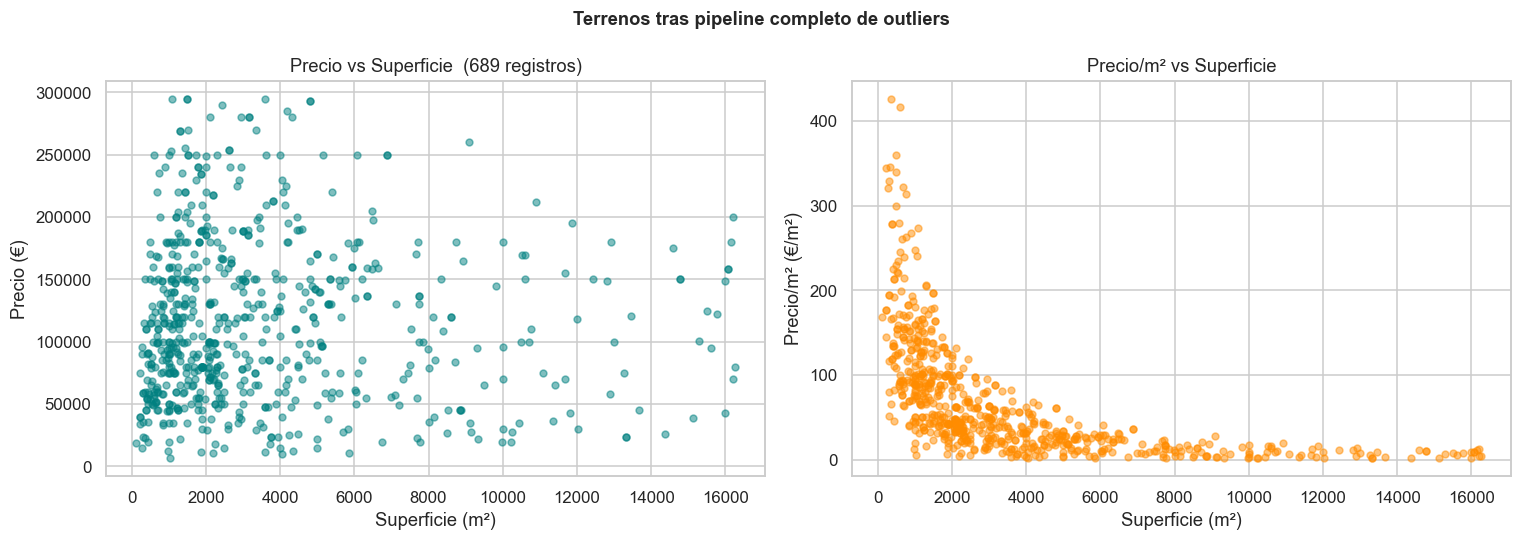

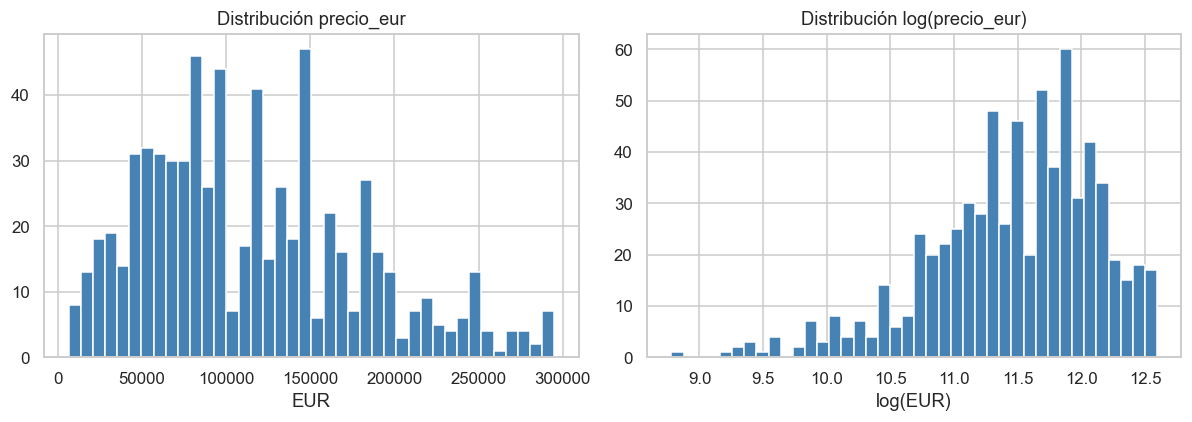

Skewness precio_eur:      0.6311
Skewness log(precio_eur): -0.8211


In [5]:
# ── Paso 0: copia de trabajo ─────────────────────────────────────────────
land_pipe = df_final.copy()
print(f"Original: {len(land_pipe):,} registros")

# ── Paso 1: Regla fija ────────────────────────────────────────────────────
land_paso1 = land_pipe[mask_rf_land(land_pipe)].reset_index(drop=True)
elim_p1    = len(land_pipe) - len(land_paso1)
print(f"\nPaso 1 – Regla fija:")
print(f"  {len(land_pipe):,} → {len(land_paso1):,}  (eliminados: {elim_p1:,})")

# ── Paso 2: IQR ×3.0 multivariante ───────────────────────────────────────
IQR_COLS_LAND = ['precio_eur', 'superficie_m2', 'precio_m2']
mask_iqr3     = mask_iqr_land(land_paso1, IQR_COLS_LAND, 3.0)
land_paso2    = land_paso1[~mask_iqr3].reset_index(drop=True)
elim_p2       = len(land_paso1) - len(land_paso2)
print(f"\nPaso 2 – IQR ×3.0:")
print(f"  {len(land_paso1):,} → {len(land_paso2):,}  (eliminados: {elim_p2:,})")

# ── Paso 3: Regla de negocio (precio > 300.000 €) ─────────────────────────
mask_precio_max = land_paso2['precio_eur'] > 300_000
land_paso3      = land_paso2[~mask_precio_max].reset_index(drop=True)
elim_p3         = len(land_paso2) - len(land_paso3)
print(f"\nPaso 3 – Precio > 300.000 €:")
print(f"  {len(land_paso2):,} → {len(land_paso3):,}  (eliminados: {elim_p3:,})")

# ── Paso 4: IQR ×1.5 sobre precio_eur ────────────────────────────────────
Q1  = land_paso3['precio_eur'].quantile(0.25)
Q3  = land_paso3['precio_eur'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print(f"\nPaso 4 – IQR ×1.5 sobre precio_eur:")
print(f"  Q1={Q1:,.0f} € | Q3={Q3:,.0f} € | IQR={IQR:,.0f} €")
print(f"  Límite inferior: {limite_inf:,.0f} € | Límite superior: {limite_sup:,.0f} €")

mask_iqr15     = (land_paso3['precio_eur'] >= limite_inf) & (land_paso3['precio_eur'] <= limite_sup)
df_land_outliers = land_paso3[mask_iqr15].reset_index(drop=True)
elim_p4        = len(land_paso3) - len(df_land_outliers)
print(f"  {len(land_paso3):,} → {len(df_land_outliers):,}  (eliminados: {elim_p4:,})")

total_elim = elim_p1 + elim_p2 + elim_p3 + elim_p4
print(f"\nTOTAL eliminados: {total_elim:,}  ({100*total_elim/len(land_pipe):.1f}%)")
print(f"Dataset final:    {len(df_land_outliers):,} registros")

# ── Scatter post-pipeline ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Terrenos tras pipeline completo de outliers', fontsize=12, fontweight='bold')

axes[0].scatter(df_land_outliers['superficie_m2'], df_land_outliers['precio_eur'],
                alpha=0.5, s=20, color='teal')
axes[0].set_title(f'Precio vs Superficie  ({len(df_land_outliers):,} registros)')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€)')

axes[1].scatter(df_land_outliers['superficie_m2'], df_land_outliers['precio_m2'],
                alpha=0.5, s=20, color='darkorange')
axes[1].set_title('Precio/m² vs Superficie')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio/m² (€/m²)')

plt.tight_layout()
plt.show()

# ── Distribución final de precio_eur ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_land_outliers['precio_eur'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución precio_eur')
axes[0].set_xlabel('EUR')

axes[1].hist(np.log(df_land_outliers['precio_eur']), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución log(precio_eur)')
axes[1].set_xlabel('log(EUR)')

plt.tight_layout()
plt.show()

print(f'Skewness precio_eur:      {df_land_outliers["precio_eur"].skew():.4f}')
print(f'Skewness log(precio_eur): {np.log(df_land_outliers["precio_eur"]).skew():.4f}')

In [6]:
# EXPORT_OUTLIERS_TERRENOS
if 'df_land_outliers' not in globals():
    raise NameError("No existe df_land_outliers. Ejecuta antes la sección del pipeline.")

processed_base_candidates = [
    Path("data/processed"),
    Path("../../data/processed")
]
processed_base = next((p for p in processed_base_candidates if p.exists()), Path("data/processed"))

processed_dir = processed_base / "scraping_manual"
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "total_land_cantabria_outliers.csv"
df_land_outliers.to_csv(output_path, sep=';', index=False, encoding='utf-8')

print(f"Dataset exportado en: {output_path.resolve()}")
print(f"Registros: {len(df_land_outliers):,}")

Dataset exportado en: /Users/sitomachucas/Documents/BezanillaSL/data/processed/scraping_manual/total_land_cantabria_outliers.csv
Registros: 689
